In [3]:
# Import Library
import pandas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [4]:
# Import Dataset
dataset = pandas.read_csv('/content/sample_data/weatherHistory.csv')

In [5]:
# Check Dataset
print(dataset.columns)

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')


In [6]:
# Feature Selection -> memilih atribut yang hanya kt perlukan dan buang yang tidak diperlukan

dataset = dataset.drop(['Formatted Date', 'Summary', 'Precip Type', 'Loud Cover', 'Daily Summary'], axis=1)

In [7]:
# Check Dataset 2 (apakah columnya udah dihapus atau belum)
print(dataset.columns)

Index(['Temperature (C)', 'Apparent Temperature (C)', 'Humidity',
       'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)',
       'Pressure (millibars)'],
      dtype='object')


In [8]:
# Menentukan feature yang akan menjadi target dan non target

# Non Target Features -> semua feature yang digunakan untuk menebak Humidity
non_target_features = dataset.drop(['Humidity'], axis=1)

# Target Feature -> feature yang ingin ditebak
target_features = dataset['Humidity']

In [9]:
# Split Data
# Ratio -> 80 (training) : 10 (testing) : 10 (validation)

x_train, x_temp, y_train, y_temp = train_test_split(non_target_features, target_features, test_size=0.2, random_state=19)

# Pembagian Testing and Validation
x_test, x_val, y_test, y_val = train_test_split(x_temp, y_temp, test_size=0.5, random_state=19)

In [10]:
# Standarisasi Data

# 1. Buat Scaler
scales = StandardScaler()

# 2. Standarisasi Data
# Training -> fit transform
x_train = scales.fit_transform(x_train)

# Testing and Validating -> transform
x_test = scales.transform(x_test)
x_val = scales.transform(x_val)

In [11]:
# Build Model

model = Sequential([
    Dense(32, activation="relu", input_dim= x_train.shape[1]),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1, activation="linear")
])

# Compile Model
model.compile(optimizer="adam", loss="mae", metrics=["mean_squared_error"])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Model Training

history = model.fit(x_train, y_train, epochs=100, batch_size=256, validation_data=(x_val, y_val))

Epoch 1/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1827 - mean_squared_error: 0.0744 - val_loss: 0.1028 - val_mean_squared_error: 0.0186
Epoch 2/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0963 - mean_squared_error: 0.0167 - val_loss: 0.0949 - val_mean_squared_error: 0.0163
Epoch 3/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0922 - mean_squared_error: 0.0155 - val_loss: 0.0921 - val_mean_squared_error: 0.0155
Epoch 4/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0901 - mean_squared_error: 0.0149 - val_loss: 0.0903 - val_mean_squared_error: 0.0150
Epoch 5/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0883 - mean_squared_error: 0.0144 - val_loss: 0.0887 - val_mean_squared_error: 0.0147
Epoch 6/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0867 - mean_squared_error: 0.0140 - val_loss: 0.0872 - val_mean_squared_error: 0.0145
Epoch 7/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0857 - mean_squared_error: 0.0137 - val_los

In [13]:
# Model Evaluation

loss, mse = model.evaluate(x_test, y_test)
print("Loss:", loss)
print("MSE:", mse)


302/302 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0781 - mean_squared_error: 0.0116
Loss: 0.07807311415672302
MSE: 0.011567937210202217


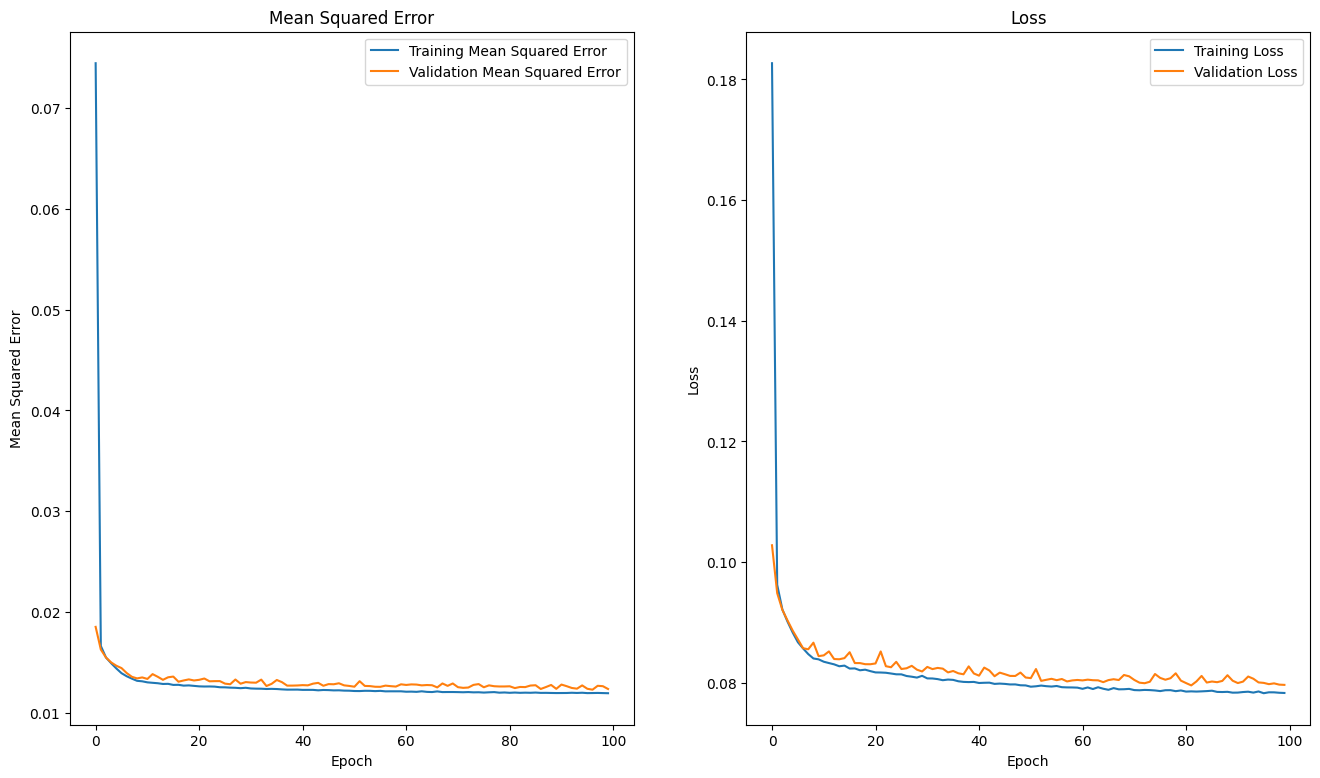

In [ ]:
# Evaluasi Menggunakan Plotting

plt.figure(figsize=(16, 9))
plt.subplot(1, 2, 1)

# sebelah kiri -> mse
plt.plot(history.history['mean_squared_error'], label = "Training Mean Squared Error")
plt.plot(history.history['val_mean_squared_error'], label = "Validation Mean Squared Error")
plt.title("Mean Squared Error")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()

# sebelah kanan -> loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Save hasilnya
# plt.savefig("Model_Evaluation.png")

# Show hasilnya
plt.show()

In [15]:
# Prediction Using Model

# 1. Buat list kosong -> prediction values, actual values
prediction_values = []
actual_values = []

# 2. Predict
predictions = model.predict(x_test[:5])
actual = y_test[:5].values

# 3. Masukkan hasil prediksi ke dalam list
for value in predictions:
  prediction_values.append(value[0])

# 4. Masukkan hasil aktual ke dalam list
for value in y_test:
  actual_values.append(value)

# 5. Print hasilnya
print("Actual                          Predicted")
print("==========================================")
for (predicted, actual) in zip(prediction_values, actual_values):
  print(f"{actual}                        {predicted}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Actual                          Predicted
0.8                        0.8302236795425415
1.0                        0.9840900897979736
0.65                        0.7301604747772217
0.39                        0.4175264835357666
0.41                        0.4182620644569397
